## Task 4: Latent Space Analysis and Error Inspection

In this task, you will analyze the internal feature representation learned by the best model obtained in Task 3. Deep neural networks transform input images into increasingly abstract representations through multiple layers. The output of the final hidden layer before the classification layer can be interpreted as a latent feature representation of the images.

By visualizing this latent space, it is possible to gain insights into how the model organizes the data and why certain samples may be misclassified.

Create a new notebook named `latentspace.ipynb`. Use the best performing model from Task 3.

### 1. Load the trained model
- Load the best model obtained.
- Ensure the model is set to evaluation mode.
- Modify the network so that it outputs the feature vector from the last hidden layer instead of the final classification layer.

### 2. Extract latent representations
- Pass all images from the validation or test dataset through the model.
- For each image, extract the latent feature vector from the last hidden layer.
- Store for each sample:
  - the (flattened) latent feature vector,
  - the ground-truth label,
  - the predicted label,
  - the prediction confidence.

### 3. Dimensionality reduction
- Since the latent vectors are high-dimensional, reduce their dimensionality to two dimensions for visualization.
- Apply the following methods:
  - PCA
  - t-SNE
- Plot the 2D latent space obtained with both methods.
- Color the samples according to their ground-truth class label.

### 4. Comparison of PCA and t-SNE
- Compare the latent space structure obtained with PCA and t-SNE.
- Investigate whether the classes appear more clearly separated with one method than the other.

### 5. Inspection of misclassified samples
- Display several misclassified test images along with:
  - their ground-truth label,
  - the predicted label,
  - the prediction confidence.
- Compare these samples with nearby correctly classified samples in the latent space.

---

In your report, discuss the results of this analysis and address the following points:

- **Latent space structure:** Do healthy knees and severe osteoarthritis cases form distinct clusters in the latent space?
- **Dimensionality reduction methods:** What differences do you observe between the PCA and t-SNE visualizations? Describe your observations regarding the latent space structure.
- **Misclassified samples:** Where do misclassified samples appear in the latent space?
- **Interpretation:** What can these observations tell you about the model's behavior and the intrinsic difficulty of the classification task?

# 1. Select a Trained Classifier — Baseline CNN

We use the best-performing baseline CNN from Task 2 (lr=0.001, dropout=0.5, trained on train+val, 30 epochs).

In [ ]:
import sys
import os
import torch
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import datasets
from sklearn.metrics import f1_score, accuracy_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.manifold import trustworthiness

# add the directory of our general py functions
sys.path.insert(0, "../0_generalcode")
from img_helper import show_images
from gpu_helper import settest_torch_gpu
from pipeline_helper import MyPreprocess, MyToTensor
from model_helper import BestModel

In [4]:
device = settest_torch_gpu()

PyTorch CUDA available: True
GPU: NVIDIA GeForce RTX 4070 Laptop GPU
Prediction shape: (5, 1)  — running on device: cuda


In [5]:
DATA_DIR = "../../data/1_source/"

test_dataset = datasets.ImageFolder(
    os.path.join(DATA_DIR, "test"), transform=MyPreprocess()
)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Test samples: {len(test_dataset)}")
print(f"Classes: {test_dataset.classes}")

Test samples: 146
Classes: ['0', '1']


In [6]:
MODEL_PATH = "../2_basemodel/baseline_best.pth"
model = BestModel.load(MODEL_PATH, device)
print("Model loaded successfully!")

Model loaded successfully!


In [7]:
all_probs = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images).squeeze(1)
        probs = torch.sigmoid(outputs)
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.numpy())

all_probs = np.array(all_probs)
all_labels = np.array(all_labels)
all_preds = (all_probs >= 0.5).astype(int)

print(f"Test samples: {len(all_labels)}")
print(f"Accuracy: {accuracy_score(all_labels, all_preds):.4f}")
print(f"F1 Score: {f1_score(all_labels, all_preds):.4f}")

Test samples: 146
Accuracy: 0.9795
F1 Score: 0.9709


In [8]:
# setting the global colors and labels used for analysis
CLASS_VALUES = [0, 1]
CLASS_NAMES = ["Healthy", "OA"]
CLASS_COLORS = ["blue", "red"]

# 2. Extract Latent Representations

The **last hidden layer** is the 128-dimensional ReLU output exposed by  --
the representation the network builds just before the final classification head.

In [9]:
all_features = []

with torch.no_grad():
    for images, _ in test_loader:
        images = images.to(device)
        feats = model.latent(images)  # use the latent layer of our model
        all_features.extend(feats.cpu().numpy())

all_features = np.array(all_features)  # (N, 128)
print(f"Feature matrix: {all_features.shape}")
print(f"Labels shape  : {all_labels.shape}")

Feature matrix: (146, 128)
Labels shape  : (146,)


In [10]:
# normalize the features
features_scaled = StandardScaler().fit_transform(all_features)

## Feature Matrix Visualisation

Two complementary views of the `(146, 128)` latent feature matrix:

- **Heatmap** — each row is one sample (sorted by class), each column is one of the 128 latent features. Colour = standardised activation. Reveals which feature blocks fire differently per class.
- **Mean activation per feature** — average activation of each feature dimension for Healthy vs OA samples. Highlights the most discriminative dimensions.

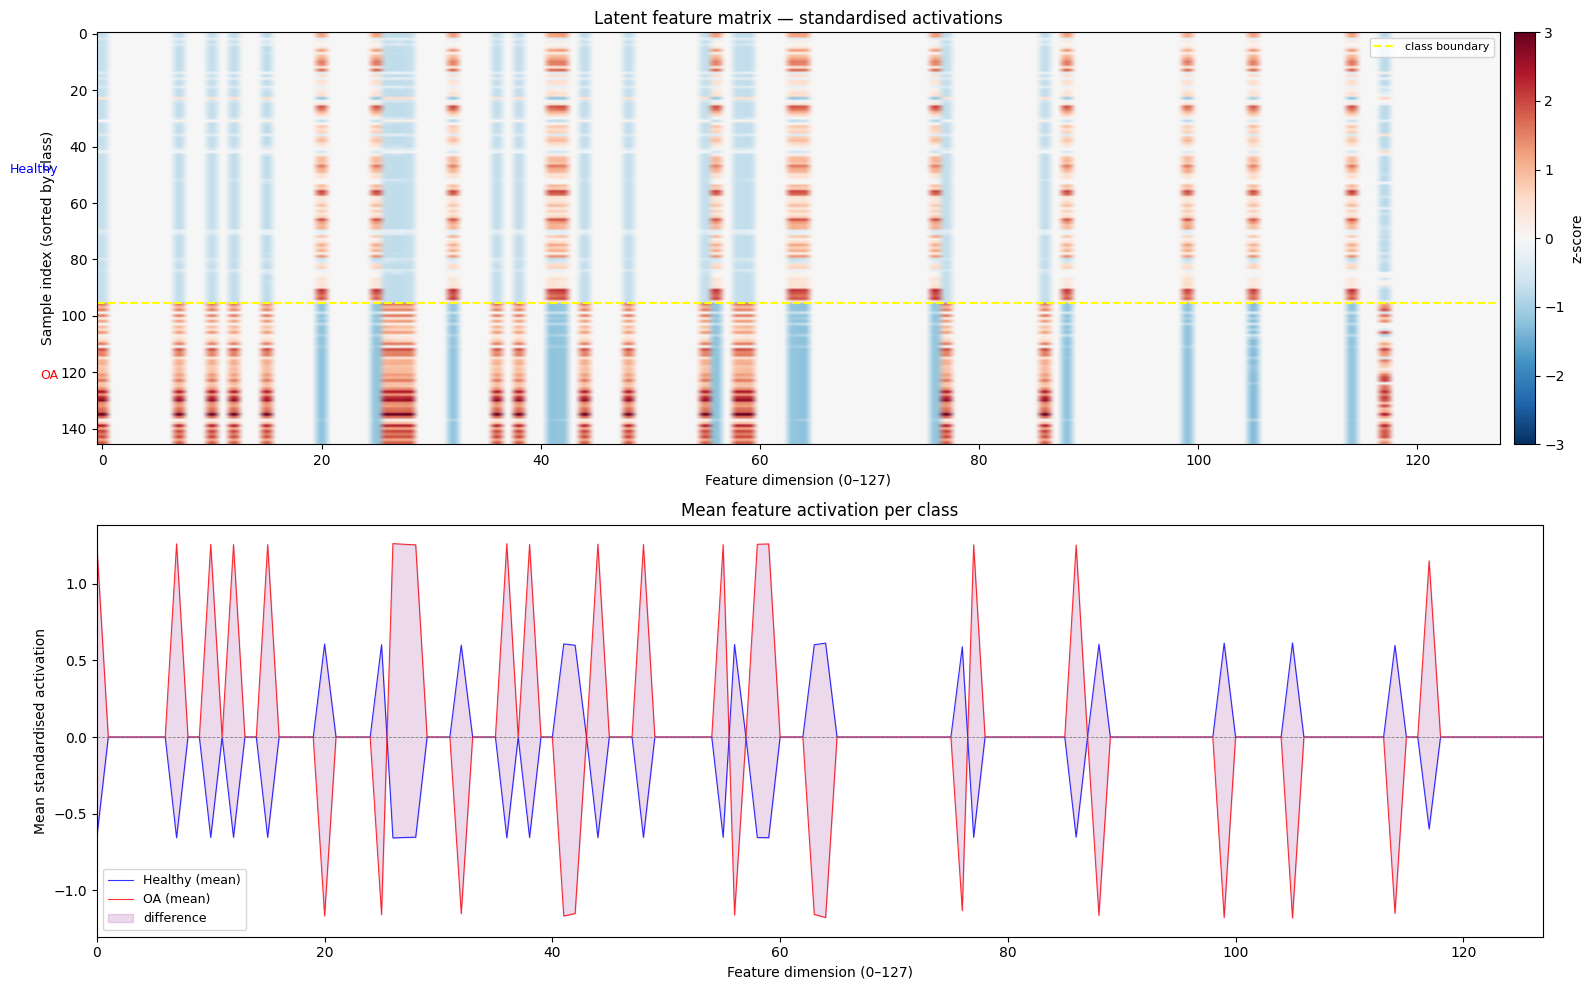

In [11]:
# sort samples by ground-truth label so classes appear as distinct bands
sort_idx = np.argsort(all_labels)
sorted_features = features_scaled[sort_idx]
sorted_labels = all_labels[sort_idx]

# boundary between class 0 and class 1
class_boundary = np.searchsorted(sorted_labels, 1)

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# --- heatmap ---
ax = axes[0]
im = ax.imshow(sorted_features, aspect="auto", cmap="RdBu_r", vmin=-3, vmax=3)
ax.axhline(
    class_boundary - 0.5,
    color="yellow",
    linewidth=1.5,
    linestyle="--",
    label="class boundary",
)
ax.set_xlabel("Feature dimension (0–127)")
ax.set_ylabel("Sample index (sorted by class)")
ax.set_title("Latent feature matrix — standardised activations")
ax.legend(loc="upper right", fontsize=8)
fig.colorbar(im, ax=ax, fraction=0.02, pad=0.01, label="z-score")

n0 = class_boundary
n1 = len(sorted_labels) - class_boundary
ax.text(
    -4,
    n0 / 2,
    CLASS_NAMES[0],
    va="center",
    ha="right",
    fontsize=9,
    color=CLASS_COLORS[0],
    clip_on=False,
)
ax.text(
    -4,
    n0 + n1 / 2,
    CLASS_NAMES[1],
    va="center",
    ha="right",
    fontsize=9,
    color=CLASS_COLORS[1],
    clip_on=False,
)

# --- mean activation per feature per class ---
ax2 = axes[1]
x = np.arange(features_scaled.shape[1])
means = [
    features_scaled[all_labels == cls].mean(axis=0) for cls in range(len(CLASS_NAMES))
]

for cls, (name, color, mean) in enumerate(zip(CLASS_NAMES, CLASS_COLORS, means)):
    ax2.plot(x, mean, color=color, alpha=0.8, linewidth=0.8, label=f"{name} (mean)")

ax2.fill_between(x, means[0], means[1], alpha=0.15, color="purple", label="difference")
ax2.axhline(0, color="gray", linewidth=0.6, linestyle="--")
ax2.set_xlabel("Feature dimension (0–127)")
ax2.set_ylabel("Mean standardised activation")
ax2.set_title("Mean feature activation per class")
ax2.legend(fontsize=9)
ax2.set_xlim(0, features_scaled.shape[1] - 1)

plt.tight_layout()
plt.show()

## Feature Importance

Two complementary metrics for each of the 128 latent dimensions:

| Metric | What it measures |
|---|---|
| **Mean absolute difference** | Raw activation gap between classes (same scale as the features) |
| **Cohen's d** | Standardised effect size — accounts for within-class spread, so features with a large gap *and* low variance score highest |

Top-20 features are plotted for each metric. High overlap between the two rankings indicates robust discriminative dimensions.

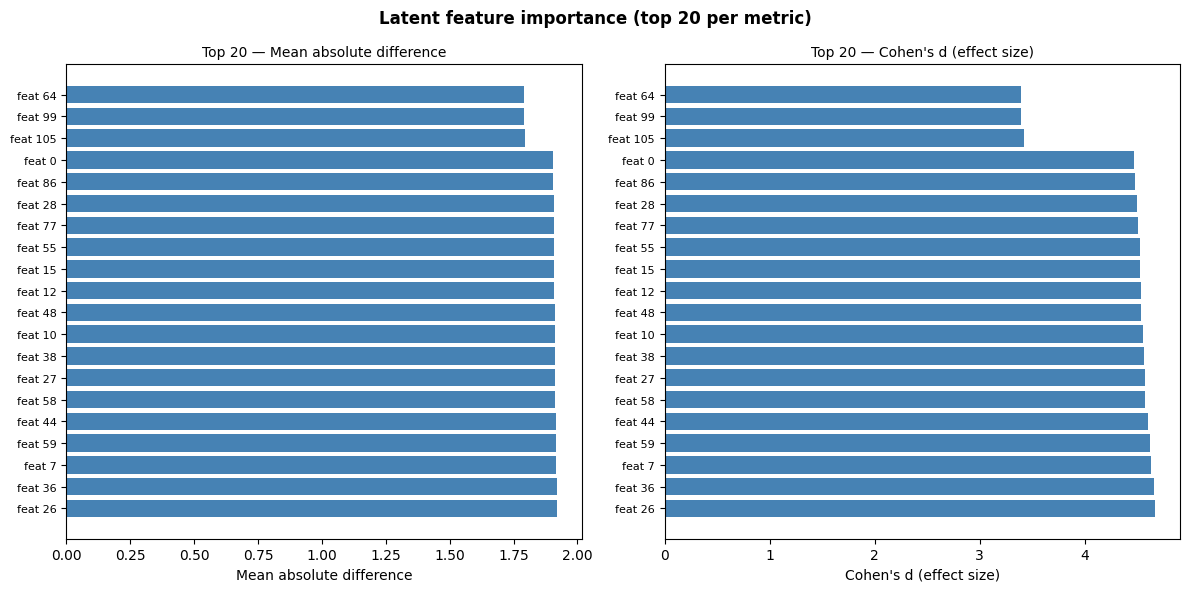

Features in top-20 for both metrics (20): [np.int64(0), np.int64(7), np.int64(10), np.int64(12), np.int64(15), np.int64(26), np.int64(27), np.int64(28), np.int64(36), np.int64(38), np.int64(44), np.int64(48), np.int64(55), np.int64(58), np.int64(59), np.int64(64), np.int64(77), np.int64(86), np.int64(99), np.int64(105)]


In [12]:
feats_per_class = [features_scaled[all_labels == cls] for cls in CLASS_VALUES]
top_n = 20

# --- metric 1: mean absolute difference ---
mean_diff = np.abs(means[0] - means[1])

# --- metric 2: Cohen's d (standardised effect size) ---
pooled_std = np.sqrt(
    (
        (feats_per_class[0].shape[0] - 1) * feats_per_class[0].var(axis=0)
        + (feats_per_class[1].shape[0] - 1) * feats_per_class[1].var(axis=0)
    )
    / (features_scaled.shape[0] - 2)
)
cohens_d = np.abs(means[0] - means[1]) / (pooled_std + 1e-8)

metrics = [
    ("Mean absolute difference", mean_diff),
    ("Cohen's d (effect size)", cohens_d),
]

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

for ax, (title, scores) in zip(axes, metrics):
    top_idx = np.argsort(scores)[::-1][:top_n]
    top_scores = scores[top_idx]

    ax.barh(range(top_n), top_scores[::-1], color="steelblue", edgecolor="none")
    ax.set_yticks(range(top_n))
    ax.set_yticklabels([f"feat {i}" for i in top_idx[::-1]], fontsize=8)
    ax.set_xlabel(title)
    ax.set_title(f"Top {top_n} — {title}", fontsize=10)
    ax.invert_yaxis()

plt.suptitle("Latent feature importance (top 20 per metric)", fontweight="bold")
plt.tight_layout()
plt.show()

# features that rank in the top-20 for both metrics
top_sets = [set(np.argsort(s)[::-1][:top_n]) for _, s in metrics]
consensus = top_sets[0] & top_sets[1]
print(
    f"Features in top-{top_n} for both metrics ({len(consensus)}): {sorted(consensus)}"
)

# 3. Dimensionality Reduction

We reduce the 128-dim latent vectors to 2D with **PCA** and **t-SNE** and
plot both embeddings coloured by ground-truth label.
Misclassified samples are additionally marked with a black cross (X).

In [13]:
pca = PCA(n_components=2, random_state=42)
feats_pca = pca.fit_transform(features_scaled)
print(
    f"PCA explained variance: {pca.explained_variance_ratio_.round(3)} "
    f"(total {pca.explained_variance_ratio_.sum():.1%})"
)

PCA explained variance: [0.911 0.084] (total 99.4%)


In [14]:
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
feats_tsne = tsne.fit_transform(features_scaled)
tsne.fit_transform(features_scaled)
print("t-SNE done")

t-SNE done


In [15]:
# ranges from 0 → 1 (1 = optimal)
t = trustworthiness(features_scaled, feats_tsne, n_neighbors=10)
print(t)

0.9967196766913347


In [16]:
score = silhouette_score(feats_tsne, all_labels)
print(score)

0.6278353333473206


#### Visual comparison

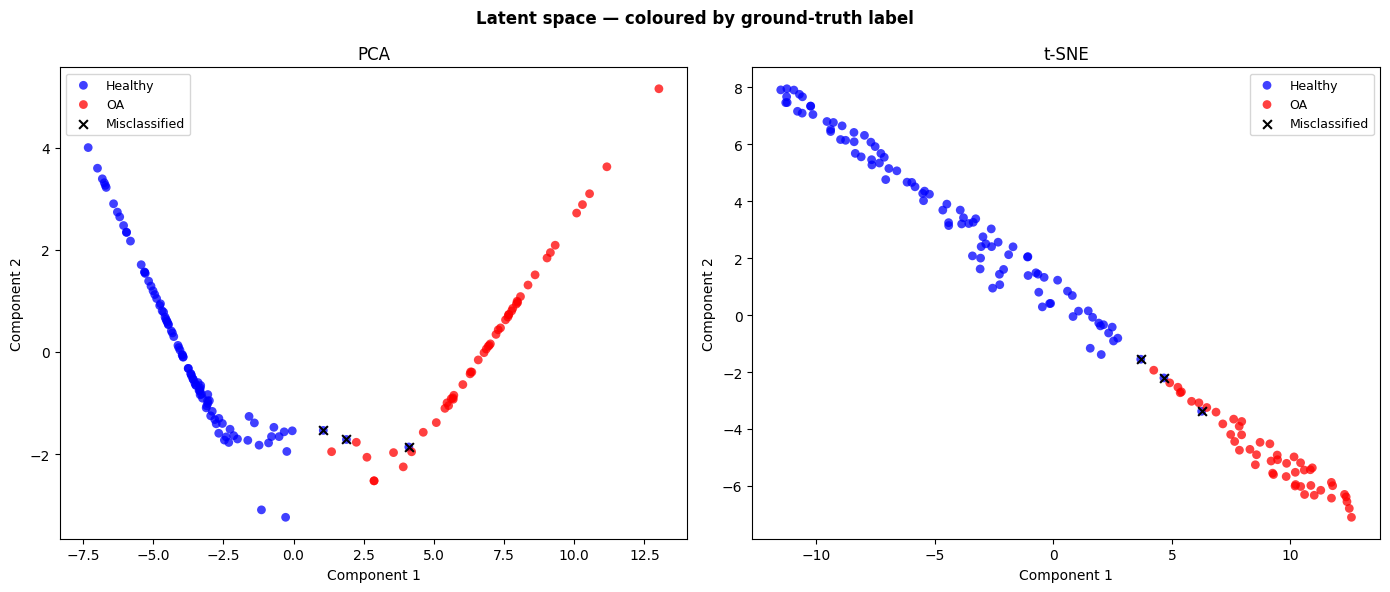

In [17]:
misc_mask = all_labels != all_preds

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (emb, title) in zip(axes, [(feats_pca, "PCA"), (feats_tsne, "t-SNE")]):
    for cls, name, color in zip(CLASS_VALUES, CLASS_NAMES, CLASS_COLORS):
        m = all_labels == cls
        ax.scatter(
            emb[m, 0],
            emb[m, 1],
            c=color,
            label=name,
            alpha=0.75,
            s=40,
            edgecolors="none",
        )
    ax.scatter(
        emb[misc_mask, 0],
        emb[misc_mask, 1],
        marker="x",
        c="black",
        s=40,
        zorder=5,
        label="Misclassified",
    )
    ax.set_title(title, fontsize=12)
    ax.legend(fontsize=9)
    ax.set_xlabel("Component 1")
    ax.set_ylabel("Component 2")

plt.suptitle("Latent space — coloured by ground-truth label", fontweight="bold")
plt.tight_layout()
plt.show()

## Parameter Sweep

### t-SNE Perplexity
Perplexity controls the balance between local and global neighbourhood structure.
Low values (5–10) emphasise tight local clusters; high values (30–50) reveal broader global topology.
Recommended range: 5–50, rule of thumb ≈ √N (here √146 ≈ 12).

### PCA — optimal n_components
Rather than comparing t-SNE plots with different pre-reduction sizes (which rarely differ visually),
we evaluate how many PCA components are needed to retain a given fraction of the total variance.
The **scree plot** shows variance per component; the **cumulative curve** shows the threshold crossings.

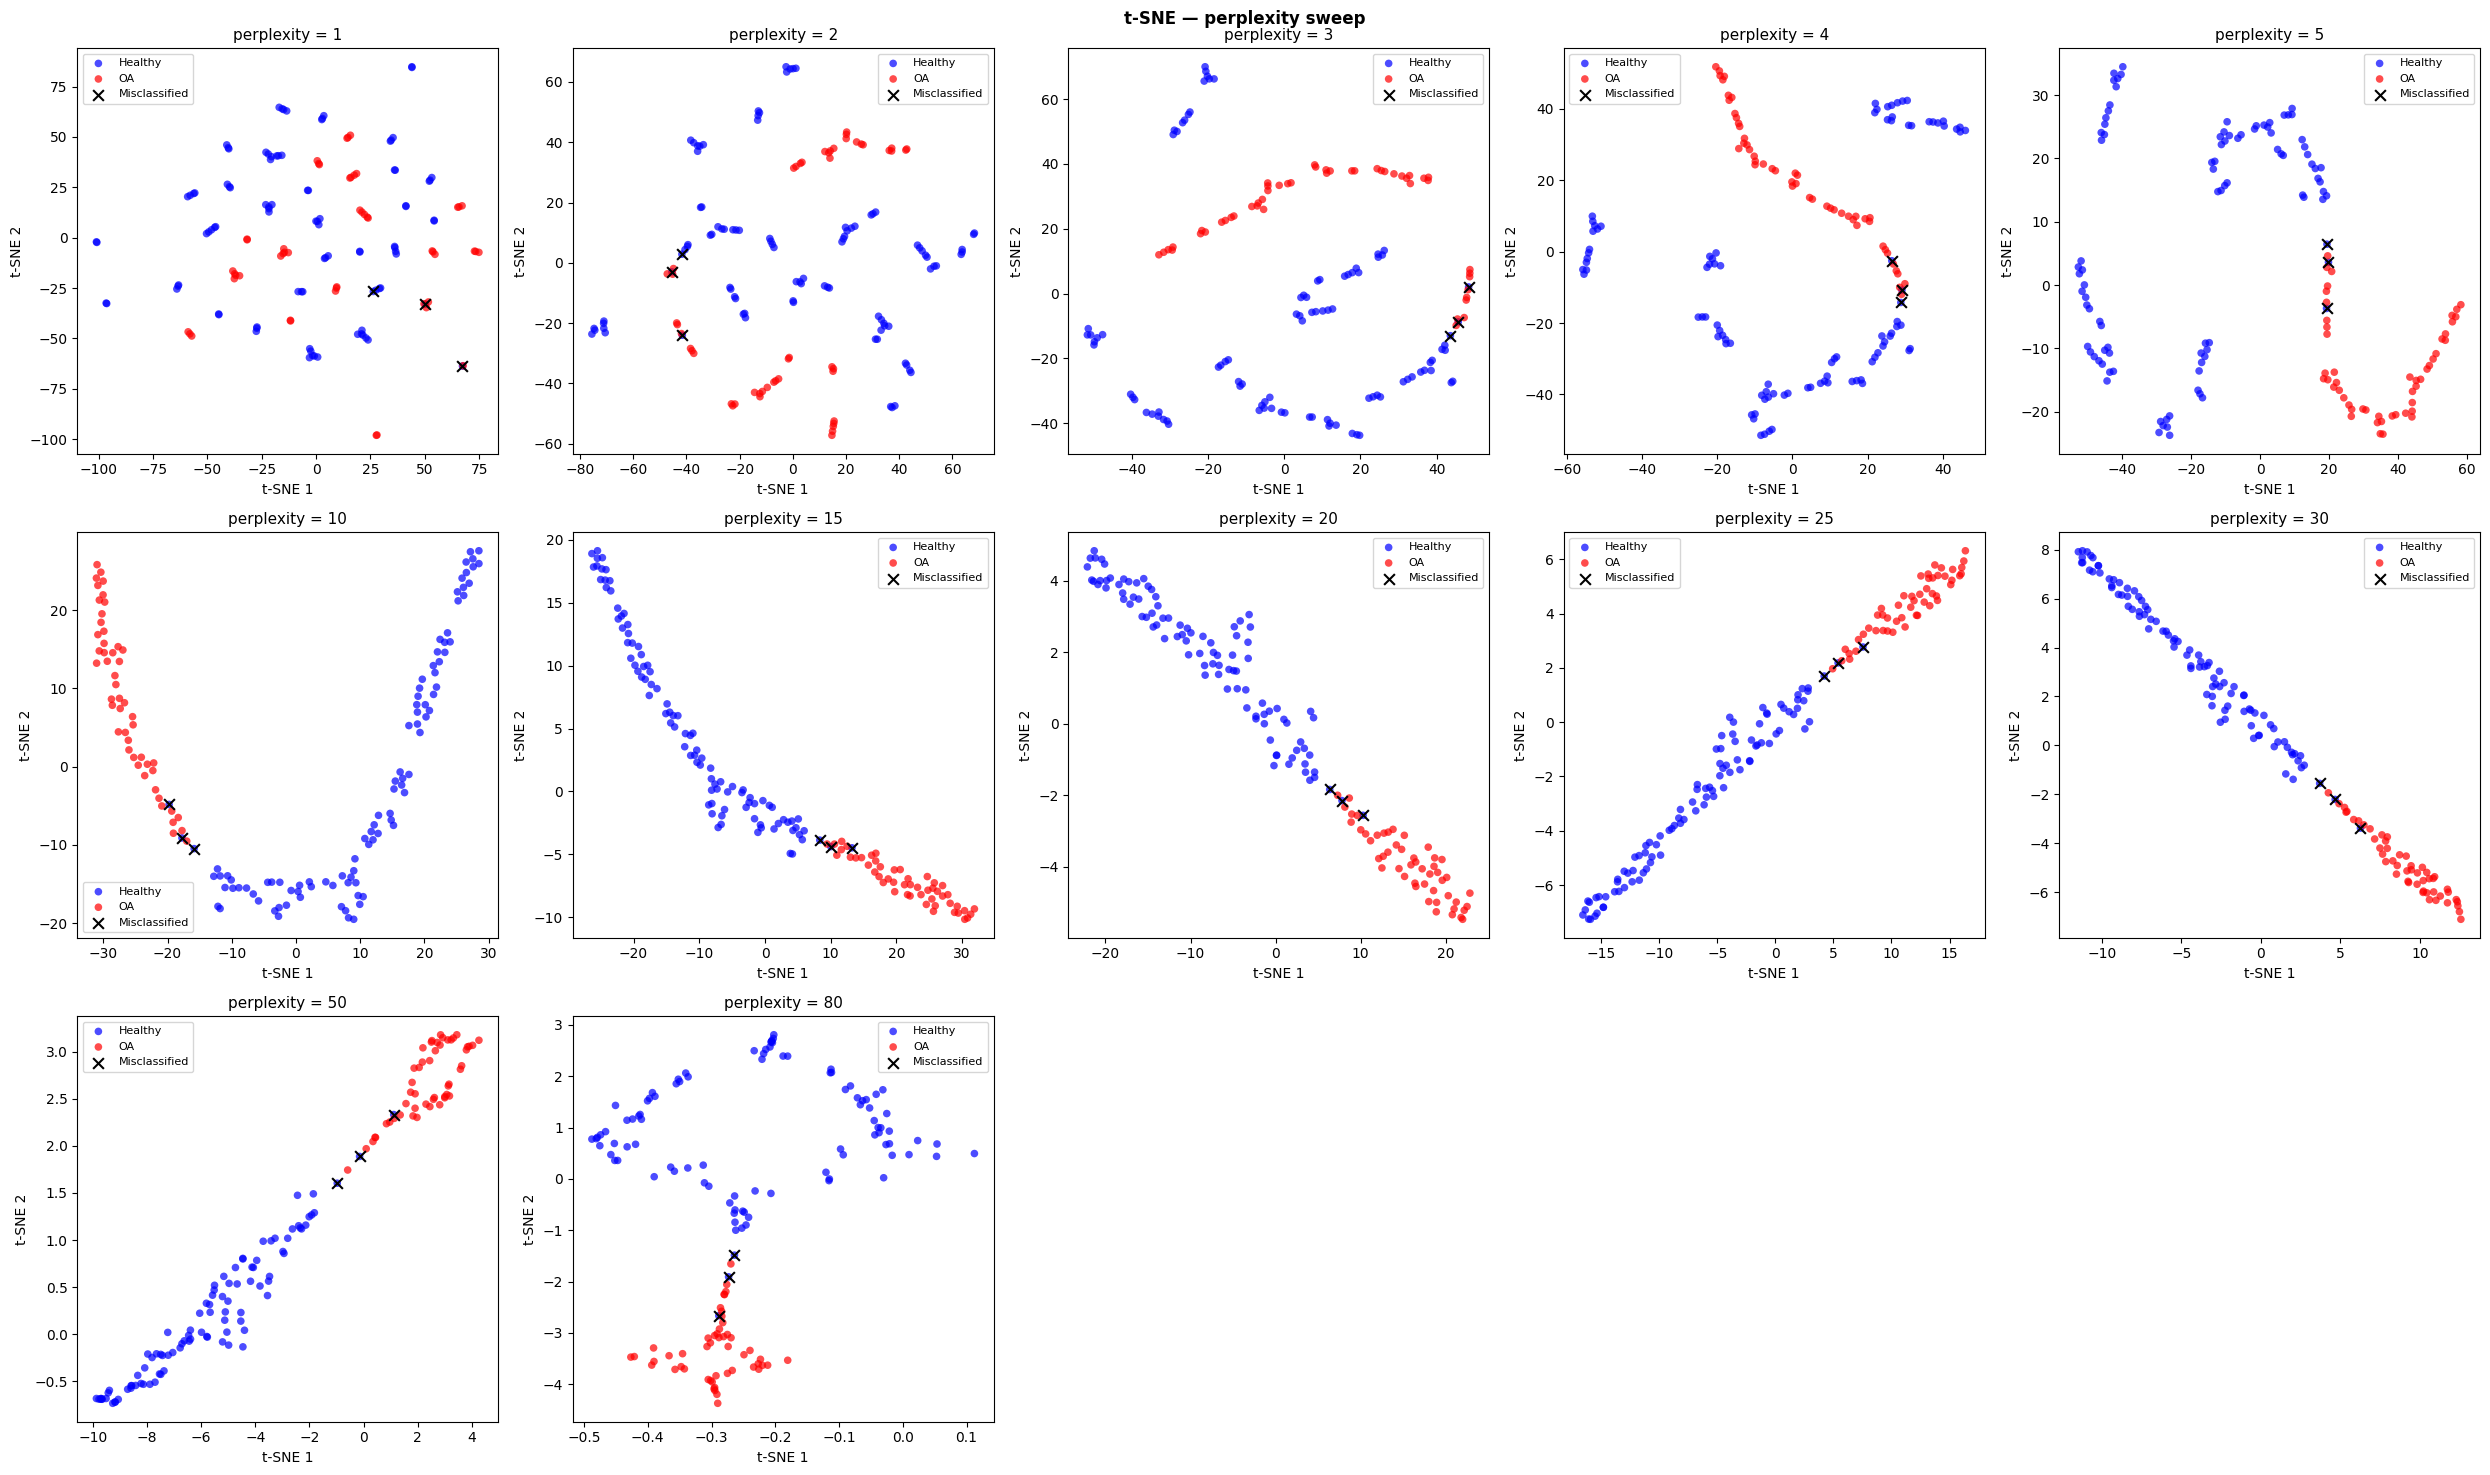

In [18]:
perplexities = [1, 2, 3, 4, 5, 10, 15, 20, 25, 30, 50, 80]

max_cols = 5
ncols = min(len(perplexities), max_cols)
nrows = (len(perplexities) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 5 * nrows), squeeze=False)

for i, p in enumerate(perplexities):
    ax = axes[i // ncols][i % ncols]
    emb = TSNE(n_components=2, perplexity=p, random_state=42).fit_transform(
        features_scaled
    )

    for cls, name, color in zip(CLASS_VALUES, CLASS_NAMES, CLASS_COLORS):
        m = all_labels == cls
        ax.scatter(
            emb[m, 0],
            emb[m, 1],
            c=color,
            label=name,
            alpha=0.7,
            s=30,
            edgecolors="none",
        )
    ax.scatter(
        emb[misc_mask, 0],
        emb[misc_mask, 1],
        marker="x",
        c="black",
        s=60,
        zorder=5,
        label="Misclassified",
    )
    ax.set_title(f"perplexity = {p}", fontsize=11)
    ax.legend(fontsize=8)
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")

for j in range(len(perplexities), nrows * ncols):
    axes[j // ncols][j % ncols].set_visible(False)

plt.suptitle("t-SNE — perplexity sweep", fontweight="bold")
plt.tight_layout()
plt.show()

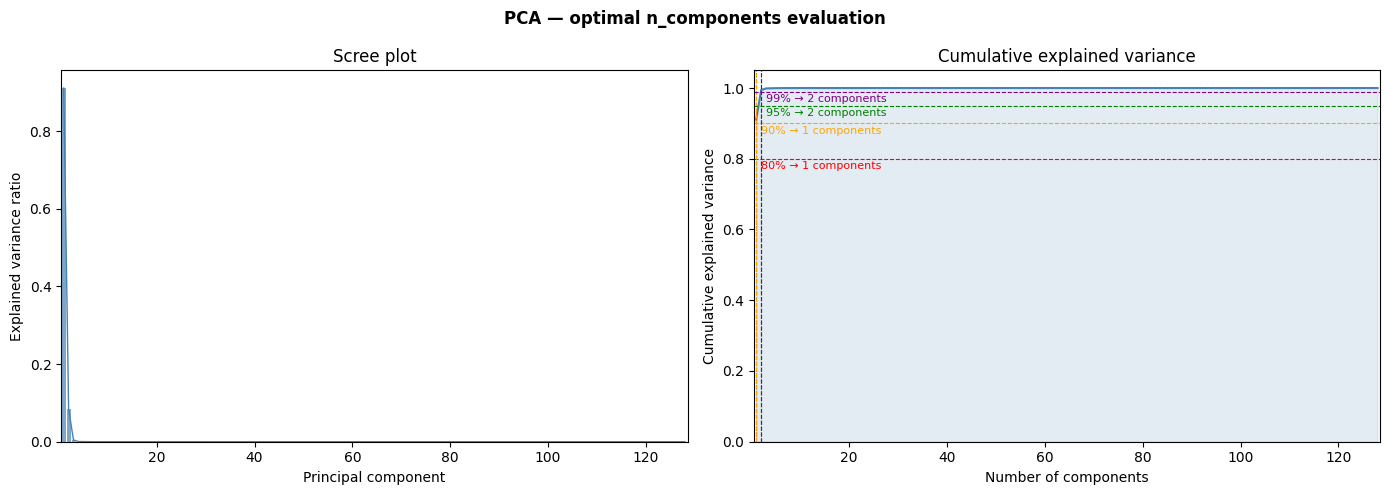

Components needed per threshold:
  80%  →  1 components  (compression 1/128 = 0.8%)
  90%  →  1 components  (compression 1/128 = 0.8%)
  95%  →  2 components  (compression 2/128 = 1.6%)
  99%  →  2 components  (compression 2/128 = 1.6%)


In [19]:
thresholds = [0.80, 0.90, 0.95, 0.99]

pca_full = PCA(random_state=42).fit(features_scaled)
evr = pca_full.explained_variance_ratio_
cumulative = np.cumsum(evr)
n_components_range = np.arange(1, len(evr) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- scree plot ---
ax = axes[0]
ax.bar(n_components_range, evr, color="steelblue", alpha=0.7, label="Individual")
ax.plot(n_components_range, evr, color="steelblue", linewidth=1)
ax.set_xlabel("Principal component")
ax.set_ylabel("Explained variance ratio")
ax.set_title("Scree plot")
ax.set_xlim(0.5, len(evr) + 0.5)

# --- cumulative explained variance ---
ax2 = axes[1]
ax2.plot(n_components_range, cumulative, color="steelblue", linewidth=1.5)
ax2.fill_between(n_components_range, cumulative, alpha=0.15, color="steelblue")

colors_thresh = ["red", "orange", "green", "purple"]
for t, c in zip(thresholds, colors_thresh):
    n_needed = int(np.searchsorted(cumulative, t)) + 1
    ax2.axhline(t, color=c, linewidth=0.8, linestyle="--")
    ax2.axvline(n_needed, color=c, linewidth=0.8, linestyle="--")
    ax2.annotate(
        f"{int(t*100)}% → {n_needed} components",
        xy=(n_needed, t),
        xytext=(n_needed + 1, t - 0.03),
        fontsize=8,
        color=c,
    )

ax2.set_xlabel("Number of components")
ax2.set_ylabel("Cumulative explained variance")
ax2.set_title("Cumulative explained variance")
ax2.set_xlim(0.5, len(evr) + 0.5)
ax2.set_ylim(0, 1.05)

plt.suptitle("PCA — optimal n_components evaluation", fontweight="bold")
plt.tight_layout()
plt.show()

print("Components needed per threshold:")
for t in thresholds:
    n = int(np.searchsorted(cumulative, t)) + 1
    print(
        f"  {int(t*100)}%  →  {n} components  (compression {n}/{features_scaled.shape[1]} = {n/features_scaled.shape[1]:.1%})"
    )

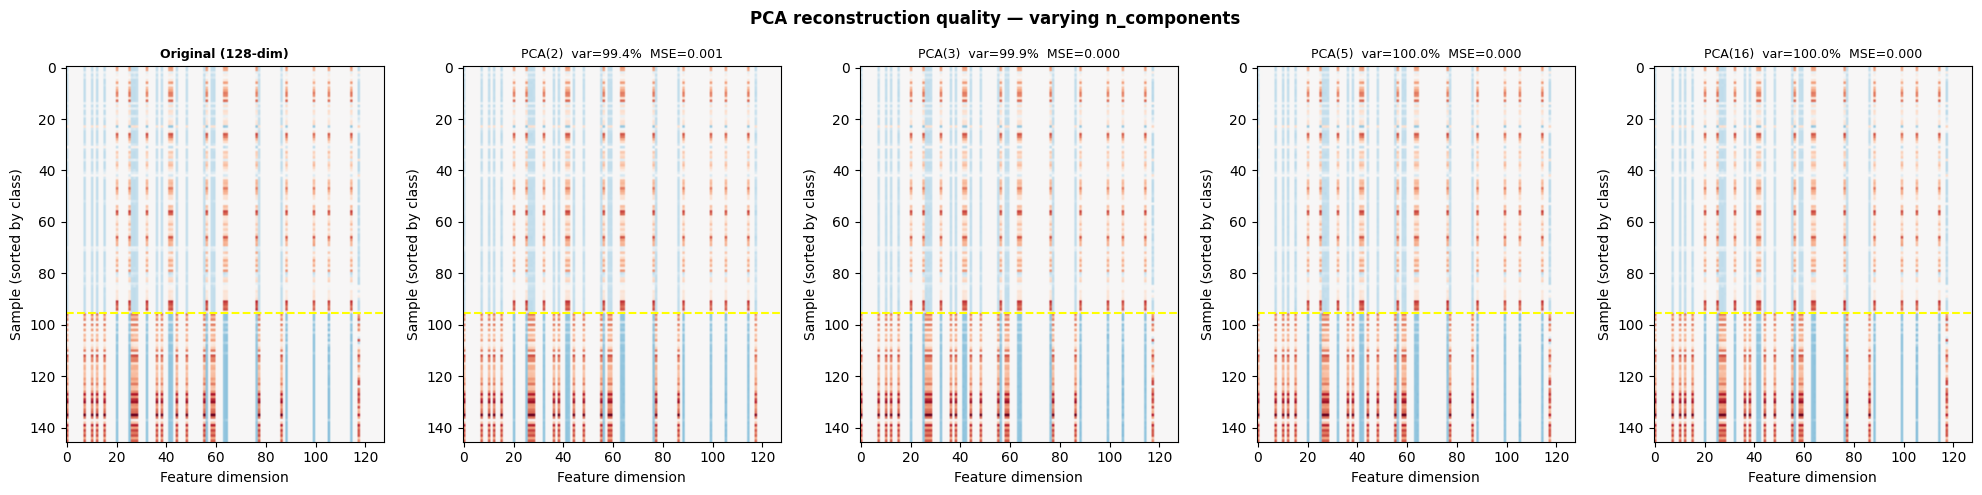

In [20]:
pca_components_list = [2, 3, 5, 16]

max_cols = 5
ncols = min(len(pca_components_list) + 1, max_cols)  # +1 for the original
nrows = (len(pca_components_list) + 1 + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 5 * nrows), squeeze=False)

# first subplot: original (reference)
ax = axes[0][0]
ax.imshow(sorted_features, aspect="auto", cmap="RdBu_r", vmin=-3, vmax=3)
ax.axhline(class_boundary - 0.5, color="yellow", linewidth=1.5, linestyle="--")
ax.set_title("Original (128-dim)", fontsize=9, fontweight="bold")
ax.set_xlabel("Feature dimension")
ax.set_ylabel("Sample (sorted by class)")

# one subplot per n_components: reconstruct and display
for i, n in enumerate(pca_components_list):
    ax = axes[(i + 1) // ncols][(i + 1) % ncols]

    pca_n = PCA(n_components=n, random_state=42)
    reduced = pca_n.fit_transform(features_scaled)
    reconstructed = pca_n.inverse_transform(reduced)
    recon_sorted = reconstructed[sort_idx]

    mse = np.mean((features_scaled - reconstructed) ** 2)
    var_exp = pca_n.explained_variance_ratio_.sum()

    ax.imshow(recon_sorted, aspect="auto", cmap="RdBu_r", vmin=-3, vmax=3)
    ax.axhline(class_boundary - 0.5, color="yellow", linewidth=1.5, linestyle="--")
    ax.set_title(f"PCA({n})  var={var_exp:.1%}  MSE={mse:.3f}", fontsize=9)
    ax.set_xlabel("Feature dimension")
    ax.set_ylabel("Sample (sorted by class)")

for j in range(len(pca_components_list) + 1, nrows * ncols):
    axes[j // ncols][j % ncols].set_visible(False)

plt.suptitle("PCA reconstruction quality — varying n_components", fontweight="bold")
plt.tight_layout()
plt.show()

# 4. Comparison of PCA and t-SNE

| | PCA | t-SNE |
|---|---|---|
| **Preserves** | global variance / linear structure | local neighbourhood structure |
| **Class separation** | Extreme — V-shape with classes diverging along PC1 (91.1% variance) | Very clear — two compact, well-separated blobs with no overlap |
| **Cluster compactness** | Both classes elongated along PC1; OA slightly more spread | Both clusters tight and round; intra-class spread minimal |
| **Outliers visible** | 3 misclassified samples sit near V-apex (decision boundary) | Misclassified samples sit at cluster edges |
| **Quantitative** | **99.4%** variance in 2D (PC1=91.1%, PC2=8.4%) | Trustworthiness=0.997; Silhouette=0.628 |

**Observations:**

Both methods confirm an extreme class separation. PCA captures **99.4%** of total variance in just 2 components — PC1 alone accounts for 91.1%. This is remarkable even by binary classification standards: the 128-dimensional latent space has essentially collapsed to a single axis. The V-shape in PCA is characteristic of a near-linear decision boundary with both classes radiating in opposite directions from the origin.

t-SNE corroborates this: trustworthiness of 0.997 (near-perfect local structure preservation) and silhouette of 0.628 indicate very compact, well-separated clusters. Only 3 of 146 samples are misclassified and they predictably sit at the cluster margins.

**Interpretation caveat:** A near-1D latent space is not necessarily a sign of good learning. It indicates the model found **one dominant global signal** that separates the classes — consistent with shortcut learning. A model that learned rich, clinically grounded features (joint space width, osteophyte texture, subchondral sclerosis) would produce a more distributed, higher-dimensional latent space. The 99.4% variance concentration in PC1 is the latent-space fingerprint of global-feature reliance, confirmed by the Score-CAM analysis.

# 5. Inspection of Misclassified Samples

We first display the misclassified images with ground-truth label, predicted label and confidence. Then we annotate their position in the latent space together with their **5 nearest neighbours** (searched in the original 128-dim feature space).

3 misclassified sample(s)


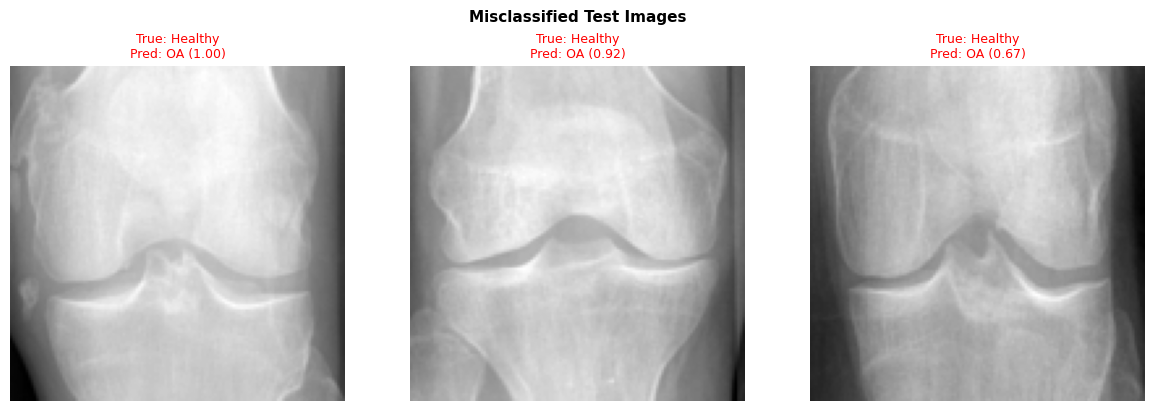

In [21]:
display_dataset = datasets.ImageFolder(
    os.path.join(DATA_DIR, "test"), transform=MyToTensor()
)

misc_idx = np.where(misc_mask)[0]
print(f"{len(misc_idx)} misclassified sample(s)")

show_images(
    misc_idx,
    display_dataset,
    all_labels,
    all_preds,
    all_probs,
    CLASS_NAMES,
    title="Misclassified Test Images",
)

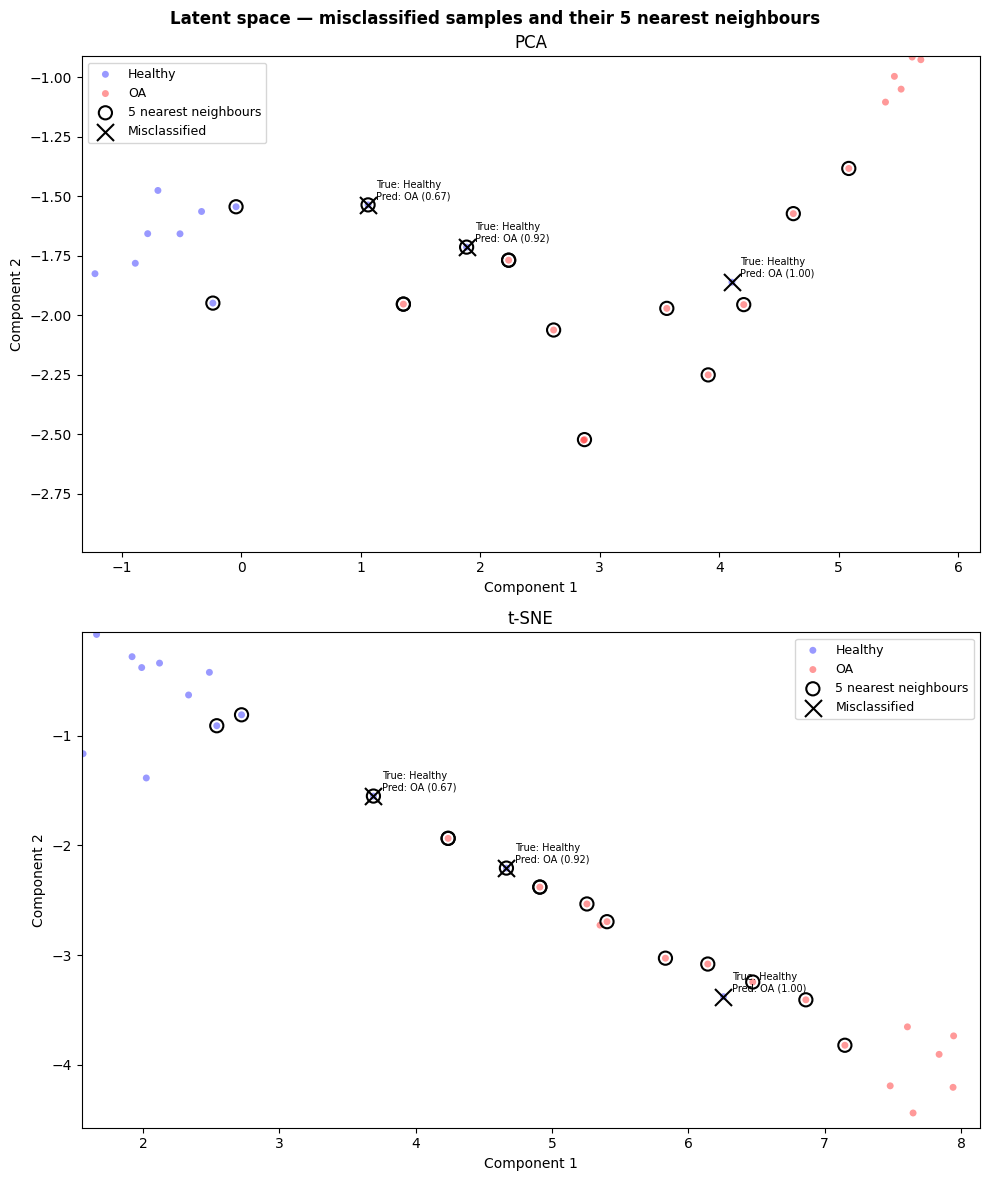

In [22]:
# 5 nearest neighbours in 128-dim feature space
knn = NearestNeighbors(n_neighbors=6)  # 6 = self + 5 neighbours
knn.fit(features_scaled)

fig, axes = plt.subplots(2, 1, figsize=(10, 12))

for ax, (emb, title) in zip(axes, [(feats_pca, "PCA"), (feats_tsne, "t-SNE")]):
    for cls, name, color in zip(CLASS_VALUES, CLASS_NAMES, CLASS_COLORS):
        m = all_labels == cls
        ax.scatter(
            emb[m, 0],
            emb[m, 1],
            c=color,
            alpha=0.4,
            s=25,
            edgecolors="none",
            label=name,
        )

    poi_x, poi_y = [], []
    first = True
    for idx in misc_idx:
        _, nbr_idx = knn.kneighbors([features_scaled[idx]])
        nbrs = nbr_idx[0][1:]

        ax.scatter(
            emb[nbrs, 0],
            emb[nbrs, 1],
            facecolors="none",
            edgecolors="black",
            s=90,
            linewidths=1.5,
            label="5 nearest neighbours" if first else "",
        )
        ax.scatter(
            emb[idx, 0],
            emb[idx, 1],
            marker="x",
            c="black",
            s=150,
            zorder=6,
            label="Misclassified" if first else "",
        )
        label_text = (
            f"True: {CLASS_NAMES[int(all_labels[idx])]}\n"
            f"Pred: {CLASS_NAMES[int(all_preds[idx])]} ({all_probs[idx]:.2f})"
        )
        ax.annotate(
            label_text,
            emb[idx],
            fontsize=7,
            ha="left",
            color="black",
            xytext=(6, 4),
            textcoords="offset points",
        )
        poi_x.extend(emb[np.append(nbrs, idx), 0])
        poi_y.extend(emb[np.append(nbrs, idx), 1])
        first = False

    pad_x = (max(poi_x) - min(poi_x)) * 0.15 + 0.3
    pad_y = (max(poi_y) - min(poi_y)) * 0.15 + 0.3
    ax.set_xlim(min(poi_x) - pad_x, max(poi_x) + pad_x)
    ax.set_ylim(min(poi_y) - pad_y, max(poi_y) + pad_y)
    ax.set_title(title, fontsize=12)
    ax.legend(fontsize=9)
    ax.set_xlabel("Component 1")
    ax.set_ylabel("Component 2")

plt.suptitle(
    "Latent space — misclassified samples and their 5 nearest neighbours",
    fontweight="bold",
)
plt.tight_layout()
plt.show()

## Misclassified samples — metadata cross-check

Cross-reference the 3 misclassified test images against the image metadata saved during preprocessing:
- **`pixel_mean`** — overall brightness; atypical values (very dark or very bright) indicate exposure outliers
- **`drop_sample`** — flagged 1 if pixel_mean < 60 (outlier threshold set in Task 1)
- **`foreign_objects`** — flagged 1 if surgical hardware or film markings were manually identified

In [ ]:
# Load image metadata saved during preprocessing
images_df = pd.read_csv(DATA_DIR + "images_info.csv")

# Map misclassified test indices → filenames
misc_filenames = [Path(test_dataset.samples[i][0]).name for i in misc_idx]
idx_map = {Path(test_dataset.samples[i][0]).name: i for i in misc_idx}

# Look up in images_df (test split only)
checks = (
    images_df[
        (images_df["split"] == "test") &
        (images_df["filename"].isin(misc_filenames))
    ][["filename", "label", "pixel_mean", "drop_sample", "foreign_objects"]]
    .copy()
)

# label is read back from CSV as int — map accordingly
checks["true_label"] = checks["label"].map({0: "Healthy", 1: "OA"})
checks["predicted"]  = checks["filename"].map(lambda f: CLASS_NAMES[int(all_preds[idx_map[f]])])
checks["confidence"] = checks["filename"].map(lambda f: f"{all_probs[idx_map[f]]:.3f}")

print(checks[["filename", "true_label", "predicted", "confidence",
              "pixel_mean", "drop_sample", "foreign_objects"]].to_string(index=False))

    filename true_label predicted confidence  pixel_mean  drop_sample  foreign_objects
9028786L.png    Healthy        OA      0.998  151.068579            0                0
9047539R.png    Healthy        OA      0.919  148.496971            0                0
9070290L.png    Healthy        OA      0.671  147.250717            0                0


Do healthy knees and severe osteoarthritis cases form distinct clusters in the latent space?

**Yes — extremely distinctly, but for a concerning reason.**

**Evidence of separation:**
- Accuracy 97.95%, F1 97.09% on 146 test samples — only 3 misclassifications.
- PCA captures **99.4%** of total variance in 2 components (PC1=91.1%, PC2=8.4%).
- t-SNE trustworthiness = 0.997 — local neighbourhood structure almost perfectly preserved.
- Silhouette = 0.628 — clear cluster separation with misclassified samples at margins.

**Why the 1D collapse is a red flag:**

A 99.4% PCA concentration means the latent representation is essentially **1-dimensional**. The model compresses the full 128×128 image into a single number on one axis that places healthy images at one end and OA images at the other.

This is the expected behaviour of a model that learned a global shortcut: one dominant image property (overall bone density, image contrast, or texture) that consistently differs between healthy and OA in this dataset. The Score-CAM analysis confirms this — neither class shows meaningful joint-space focus; the model uses the full image uniformly.

A model that genuinely learned clinical features (joint space narrowing, osteophytes, subchondral sclerosis) would produce a richer, more distributed latent space requiring several PCA components — because those features vary independently across patients.

**Model behavior:**

- The near-1D PCA structure (PC1=91.1%) reveals the model found one dominant discriminative direction — a global image property rather than a localised anatomical feature. High accuracy is real; clinical validity of the learned representation is not.
- The architecture reinforces this: the 1×1 projection to 2048 channels followed by `AdaptiveAvgPool2d(1)` collapses all spatial information before the FC layer, structurally preventing the model from retaining spatially selective features.
- The 3 misclassified samples at the cluster boundary reflect genuine ambiguity (atypical anatomy, surgical hardware) — the model is uncertain exactly where the global signal is weakest, not randomly wrong.

**Intrinsic difficulty of the task:**

- The binary framing (healthy vs. severe OA, KL grade 0 vs. 3–4) collapses a 5-class grading problem into two radiologically extreme cases. Severe OA is visibly different from a healthy joint even at 128×128, meaning a global texture difference is sufficient for ~98% accuracy — the shortcut works.
- A 5-class grading model (KL 0–4) would show far more cluster overlap, requiring genuinely localised features to discriminate adjacent grades — making the shortcut less viable and forcing the model toward clinically grounded representations.